### Passo 2: o	Classifique com modelos supervisionados (AutoAI).

#### Instalação do Ambiente

In [50]:
%pip install ibm-watsonx-ai
%pip install lale==0.8.3
%pip install scikit-learn==1.3.2
%pip install xgboost==2.0.3 
%pip install lightgbm==4.2.0 
%pip install snapml==1.14.*
%pip install autoai_libs
%pip install onnxconverter-common
%pip install flask

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
onnxconverter-common 1.14.0 requires protobuf==3.20.2, but you have protobuf 6.32.0 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for protobuf==3.20.2 from https://files.pythonhosted.org/packages/8b/e6/2a47ce2eba1aaf287380a44270da897ada03d118a55c19595ec7b4f0831f/protobuf-3.20.2-py2.py3-none-any.whl.metadata
  Using cached protobuf-3.20.2-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.2-py2.py3-none-any.whl (162 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.32.0
    Uninstalling protobuf-6.32.0:
      Successfully uninstalled protobuf-6.32.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autoai-libs 2.0.16 requires protobuf>=4.21.12, but you have protobuf 3.20.2 which is incompatible.

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Importação das Bibliotecas

##### Importação das Blibiotecas Gerais

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.metrics import classification_report
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
import config

##### Importação das Bibliotecas do Watson AI

In [52]:
from ibm_watsonx_ai import Credentials, APIClient
from ibm_watsonx_ai.experiment import AutoAI
from ibm_watsonx_ai.helpers import DataConnection, ContainerLocation
from ibm_watsonx_ai.deployment import WebService
import getpass

#### Estabelecendo Conexão com o Watson AI

In [53]:
# Define onde está localizado o dataset no IBM Cloud
training_data_references = [
    DataConnection(
        data_asset_id = config.DATA_ASSET_ID
    ),
]

# Define onde os resultados do experimento (modelos, métricas) serão armazenados
training_result_reference = DataConnection(
    location=ContainerLocation(
        path=config.RESULT_PATH,
        model_location=config.MODEL_LOCATION,
        training_status=config.TRAINING_STATUS
    )
)

In [54]:
# Metadados do experimento AutoAI (configurações da tarefa de classificação)
experiment_metadata = dict(
    prediction_type='binary', # Tipo de problema (binário)
    prediction_column='Engenharia Social?', # Nome da coluna alvo
    holdout_size=0.1, # Proporção dos dados reservados para teste
    scoring='accuracy', # Métrica principal
    csv_separator=',',
    random_state=33,
    max_number_of_estimators=2, # Número máximo de modelos testados
    training_data_references=training_data_references,
    training_result_reference=training_result_reference,
    deployment_url = config.DEPLOYMENT_URL,
    project_id = config.PROJECT_ID,
    positive_label=1,
    drop_duplicates=True,
    include_batched_ensemble_estimators=['BatchedTreeEnsembleClassifier(ExtraTreesClassifier)', 'BatchedTreeEnsembleClassifier(LGBMClassifier)', 'BatchedTreeEnsembleClassifier(RandomForestClassifier)', 'BatchedTreeEnsembleClassifier(SnapBoostingMachineClassifier)', 'BatchedTreeEnsembleClassifier(SnapRandomForestClassifier)', 'BatchedTreeEnsembleClassifier(XGBClassifier)'],
    classes=[0.0, 1.0],
    feature_selector_mode='auto'
)

In [55]:
# Detecta número de CPUs disponíveis no ambiente
import os, ast
CPU_NUMBER = 4
if 'RUNTIME_HARDWARE_SPEC' in os.environ:
    CPU_NUMBER = int(ast.literal_eval(os.environ['RUNTIME_HARDWARE_SPEC'])['num_cpu'])

In [56]:
# Cria credenciais com a API key para se conectar ao Watsonx.ai
api_key = config.API_KEY

credentials = Credentials(
    api_key=api_key,
    url=experiment_metadata['deployment_url']
)

In [57]:
# Cria cliente para manipular o Watson AI
client = APIClient(credentials)

# Define o projeto padrão onde os ativos estão armazenados
if 'space_id' in experiment_metadata:
    client.set.default_space(experiment_metadata['space_id'])
else:
    client.set.default_project(experiment_metadata['project_id'])

# Associa o cliente ao dataset carregado
training_data_references[0].set_client(client)

#### Executando o AutoAI para obter a Melhor Pipeline:

In [58]:
# Inicializa o experimento AutoAI com as credenciais e o projeto
experiment = AutoAI(credentials=credentials, project_id=experiment_metadata["project_id"])

# Executa o experimento com as configurações definidas
pipeline_optimizer = experiment.runs.get_optimizer(metadata=experiment_metadata)

In [59]:
# Gera um resumo com as pipelines testadas
df_summary = pipeline_optimizer.summary()

# Seleciona a pipeline com melhor desempenho
best_pipeline_name = df_summary.index[0]

# Recupera o pipeline treinado no formato do scikit-learn
sklearn_pipeline_model = pipeline_optimizer.get_pipeline(
    pipeline_name=best_pipeline_name,
    astype=AutoAI.PipelineTypes.SKLEARN
)

c:\Users\JuliodaSilvaNeves\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.3.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\JuliodaSilvaNeves\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.3.0 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\JuliodaSilvaNeves\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Tr

In [60]:
# Garante que o cliente está setado no projeto correto novamente
client = APIClient(credentials=credentials)
client.set.default_project(experiment_metadata["project_id"])
training_data_references[0].set_client(client)

# Recupera os dados de teste (holdout) para avaliação
_, X_test, _, y_test = training_data_references[0].read(experiment_metadata=experiment_metadata, with_holdout_split=True, use_flight=True)

In [61]:
# Avaliação do modelo com métrica de acurácia
from sklearn.metrics import accuracy_score
print("Accuracy Score:", accuracy_score(y_test.values.ravel(), sklearn_pipeline_model.predict(X_test.values)))

Accuracy Score: 0.90625


In [62]:
# Relatório detalhado de métricas: precisão, recall e F1-score
print("\nClassification Report:")
print(classification_report(y_test, sklearn_pipeline_model.predict(X_test.values)))


Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.92      0.92       180
         1.0       0.90      0.89      0.89       140

    accuracy                           0.91       320
   macro avg       0.91      0.90      0.90       320
weighted avg       0.91      0.91      0.91       320



### Passo 3: Extraia as palavras mais comuns em mensagens suspeitas.

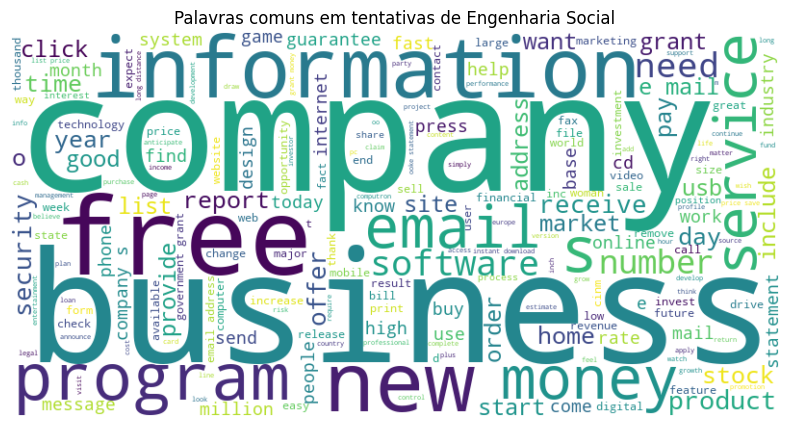

In [63]:
# Filtra os textos classificados como eng_social (rótulo = 1)
messages = X_test.loc[y_test.values.ravel() == 1, 'Conteudo'].astype(str)

# Junta todos os textos em uma única string
texto_social_eng = " ".join(messages.values)

# Gera uma nuvem de palavras com as palavras mais comuns em mensagens suspeitas
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_social_eng)

# Exibe a nuvem de palavras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Palavras comuns em tentativas de Engenharia Social")
plt.show()